2024-12-16 16:45:28 - Loading data from the database...
2024-12-16 16:48:33 - Data loaded successfully.
2024-12-16 16:48:33 - Creating 1-year ahead market cap target...
2024-12-16 16:48:35 - Target variable created.
2024-12-16 16:48:35 - Preparing features and target...
2024-12-16 16:48:35 - Splitting data into train and test sets while preserving time order...
2024-12-16 16:48:35 - Data split completed.
2024-12-16 16:48:36 - Training the ANN model from scratch...
Epoch 1/100


C:\Users\Sudhir Kulaye\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7915/7915 ━━━━━━━━━━━━━━━━━━━━ 39s 5ms/step - loss: 12423331840.0000 - mean_squared_error: 12423331840.0000 - val_loss: 16826914816.0000 - val_mean_squared_error: 16826914816.0000
Epoch 2/100
7915/7915 ━━━━━━━━━━━━━━━━━━━━ 38s 5ms/step - loss: 11929154560.0000 - mean_squared_error: 11929154560.0000 - val_loss: 16831469568.0000 - val_mean_squared_error: 16831469568.0000
Epoch 3/100
7915/7915 ━━━━━━━━━━━━━━━━━━━━ 34s 4ms/step - loss: 12118822912.0000 - mean_squared_error: 12118822912.0000 - val_loss: 16836322304.0000 - val_mean_squared_error: 16836322304.0000
Epoch 4/100
7915/7915 ━━━━━━━━━━━━━━━━━━━━ 41s 5ms/step - loss: 12039959552.0000 - mean_squared_error: 12039959552.0000 - val_loss: 16825966592.0000 - val_mean_squared_error: 16825966592.0000
Epoch 5/100
7915/7915 ━━━━━━━━━━━━━━━━━━━━ 44s 6ms/step - loss: 12175495168.0000 - mean_squared_error: 12175495168.0000 - val_loss: 16830992384.0000 - val_mean_squared_error: 16830992384.0000
Epoch 6/100
7915/7915 ━━━━━━━━━━━━━━━━━━━━ 44s 6ms/s

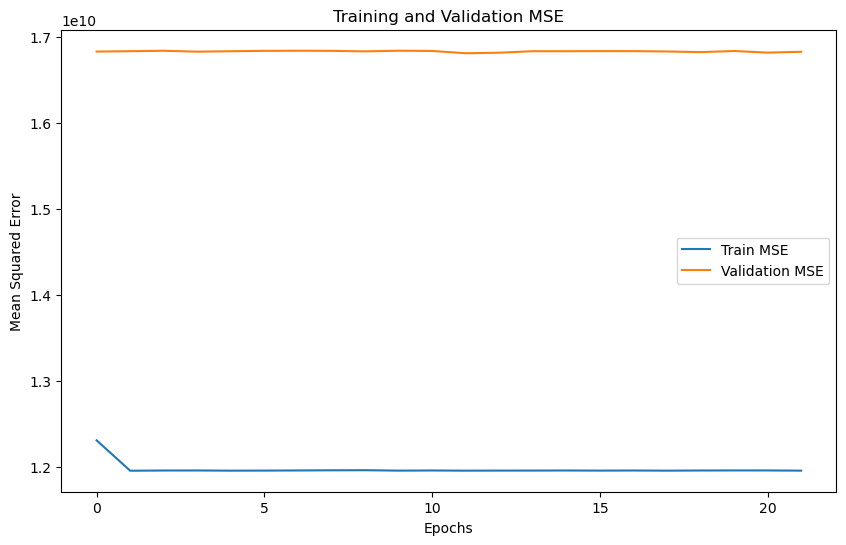

In [27]:
import pandas as pd
import numpy as np
import pymysql
from sqlalchemy import create_engine
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os

# Database connection details
host = 'localhost'
user = 'towdevuser'
password = 'Dev703'
database = 'timelineofwealth'

# Model file path
model_path = 'ann_marketcap_model.keras'

# Flag to decide if training should be done from scratch
train_from_scratch = True

# Create a database connection
engine = create_engine(f"mysql+pymysql://{user}:{password}@{host}/{database}")

# Logging function
def log(message):
    print(f"{datetime.now().strftime('%Y-%m-%d %H:%M:%S')} - {message}")

# Step 1: Load Data from Database
log("Loading data from the database...")
query = """
    SELECT * FROM daily_data_s 
    WHERE name IN (
        SELECT ticker FROM stock_universe a 
        WHERE is_nse500 = 1 OR is_bse500 = 1
    )
    ORDER BY name, date DESC;
"""
df = pd.read_sql(query, engine)
log("Data loaded successfully.")

# Step 2: Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

# Step 3: Create the target variable (1-year ahead market cap)
log("Creating 1-year ahead market cap target...")
def get_one_year_ahead_market_cap(df):
    # Ensure data is sorted by name and date
    df = df.sort_values(by=['name', 'date'])
    
    # Create a new column for the target date (exactly 1 year ahead)
    df['target_date'] = df['date'] + pd.DateOffset(years=1)
    
    # Self-join to match each row with its corresponding target date
    df_with_target = df.merge(
        df[['name', 'date', 'market_cap']],
        left_on=['name', 'target_date'],
        right_on=['name', 'date'],
        suffixes=('', '_target'),
        how='left'
    )
    
    # Rename the merged market cap column to 'target_market_cap'
    df_with_target.rename(columns={'market_cap_target': 'target_market_cap'}, inplace=True)
    
    # Drop the duplicate 'date' column from the merged result
    df_with_target.drop(columns=['date_target'], inplace=True)
    
    # Drop rows where 'target_market_cap' is missing
    df_with_target = df_with_target.dropna(subset=['target_market_cap'])
    
    return df_with_target

df = get_one_year_ahead_market_cap(df)
log("Target variable created.")

# Step 4: Feature Engineering (excluding non-numeric and target columns)
log("Preparing features and target...")
features = df.drop(columns=['name', 'rank', 'last_result_date', 'market_cap', 'sector', 'industry', 'sub_industry', 'target_date'])
features_sorted = features.sort_values(by='date')
target_sorted = features_sorted['target_market_cap']
features_sorted = features_sorted.drop(columns=['target_market_cap', 'date'])

# Step 5: Train-test split while preserving time order
log("Splitting data into train and test sets while preserving time order...")
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(features_sorted, target_sorted, test_size=0.3, shuffle=False)
log("Data split completed.")

# Step 6: Data Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 7: Define the Sequential ANN Model
def create_ann_model(input_dim):
    model = Sequential([
        Dense(128, activation='relu', input_dim=input_dim),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)  # Output layer for regression
    ])
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_squared_error'])
    return model

# Check if the model already exists and the flag for training
if os.path.exists(model_path) and not train_from_scratch:
    log("Loading existing model...")
    from tensorflow.keras.models import load_model
    model = load_model(model_path)
    log("Model loaded successfully.")
else:
    log("Training the ANN model from scratch...")
    model = create_ann_model(X_train.shape[1])

    # Callbacks for early stopping and model checkpointing
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    # Update ModelCheckpoint callback
    checkpoint = ModelCheckpoint(model_path, save_best_only=True, monitor='val_loss')

    # Train the model
    start_time = datetime.now()
    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=32,
        callbacks=[early_stopping, checkpoint],
        verbose=1
    )
    end_time = datetime.now()
    log(f"Model training completed in {end_time - start_time}.")
    log("Best model saved for future use.")

# Step 8: Evaluate the model on the test set
log("Evaluating the model on the test set...")
start_time = datetime.now()
y_pred = model.predict(X_test)
end_time = datetime.now()
log(f"Model testing completed in {end_time - start_time}.")

# Calculate performance metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

log(f"Test RMSE: {rmse:.2f}")
log(f"Test R²: {r2:.2f}")

# Plot training history (optional)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history.history['mean_squared_error'], label='Train MSE')
plt.plot(history.history['val_mean_squared_error'], label='Validation MSE')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.title('Training and Validation MSE')
plt.show()

In [19]:
def get_latest_data_and_predict(ticker, date, engine, model, scaler):
    log(f"Fetching data for ticker: {ticker} on date: {date}")

    # SQL query to fetch the data for the specified ticker and date
    query = f"""
        SELECT * FROM daily_data_s
        WHERE name = '{ticker}'
        AND date = '{date}';
    """

    # Fetch the data from the database
    latest_data = pd.read_sql(query, engine)

    if latest_data.empty:
        log(f"No data found for ticker: {ticker} on date: {date}")
        return

    # Convert date column to datetime
    latest_data['date'] = pd.to_datetime(latest_data['date'])

    # Extract relevant fields
    latest_row = latest_data.iloc[0]
    latest_date = latest_row['date']
    current_market_cap = latest_row['market_cap']

    log(f"Latest available date for {ticker}: {latest_date.strftime('%Y-%m-%d')}")

    # Prepare the test data by dropping unnecessary columns
    test_data = latest_row.drop(labels=['date', 'name', 'rank', 'last_result_date', 'market_cap', 'sector', 'industry', 'sub_industry'])

    # Convert to DataFrame with a single row
    test_data_df = pd.DataFrame([test_data])

    # Ensure columns match the training features
    test_data_df = test_data_df[features.columns]

    # Scale the test data
    test_data_scaled = scaler.transform(test_data_df)

    # Loading existing model...    # Loading existing model...
    log("Loading existing model...")
    from tensorflow.keras.models import load_model
    model = load_model(model_path)
    log("Model loaded successfully.")

    # Predict the target market cap
    predicted_market_cap = model.predict(test_data_scaled)[0][0]

    # Calculate expected percentage change
    expected_change = ((predicted_market_cap / current_market_cap) - 1) * 100

    # Print the results
    print(f"\nPrediction Results for {ticker}")
    print(f"Latest Available Date: {latest_date.strftime('%Y-%m-%d')}")
    print(f"Current Market Cap: {current_market_cap:,.2f}")
    print(f"Predicted Target Market Cap (1 year ahead): {predicted_market_cap:,.2f}")
    print(f"Expected % Change Over the Year: {expected_change:.2f}%")

# Example call for TCS with a specific date
ticker = 'AXISBANK'
date = '2024-12-13'  # Replace with the desired date in 'YYYY-MM-DD' format
get_latest_data_and_predict(ticker, date, engine, model, scaler)


2024-12-16 10:34:23 - Fetching data for ticker: AXISBANK on date: 2024-12-13
2024-12-16 10:34:23 - Latest available date for AXISBANK: 2024-12-13
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step

Prediction Results for AXISBANK
Latest Available Date: 2024-12-13
Current Market Cap: 355,330.48
Predicted Target Market Cap (1 year ahead): 50,346.66
Expected % Change Over the Year: -85.83%
